<a href="https://colab.research.google.com/github/aKrish23-luffy/Project/blob/main/Project_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [2]:
import io
data = {
    'CustomerID' : [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'Purchase_Frequency' : [2, 12, 1, 14, 3, 15, 2, 13, 1, 11],
    'Amount_Spent' : [50, 450, 60, 400, 70, 500, 45, 380, 55, 420]
}
df = pd.read_csv(io.StringIO(pd.DataFrame(data).to_csv(index=False)))

In [3]:
print(f"Dataset created with {df.shape[0]} customers and {df.shape[1]-1} features")

Dataset created with 10 customers and 2 features


In [4]:
x = df.drop("CustomerID", axis=1)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
print("Customer IDs dropped and features scaled for fair comparison.")

Customer IDs dropped and features scaled for fair comparison.


In [5]:
k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
df['SegmentID'] = kmeans.fit_predict(x_scaled)

print(f"Customers grouped into {k} different segments using K-means!")

Customers grouped into 2 different segments using K-means!


In [6]:
score = silhouette_score(x_scaled, df['SegmentID'])

In [7]:
print(f"The silhouette score is : {score:.2f}")

The silhouette score is : 0.88


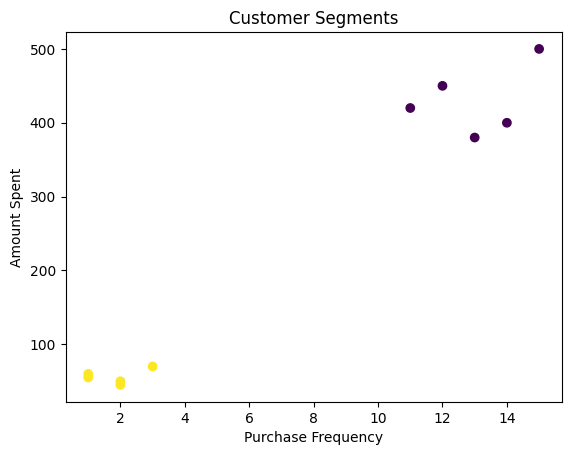

In [8]:
plt.scatter(df['Purchase_Frequency'], df['Amount_Spent'], c=df['SegmentID'])
plt.xlabel('Purchase Frequency')
plt.ylabel('Amount Spent')
plt.title('Customer Segments')
plt.show()